# 2026 World Cup Final: Spain vs. Argentina

This notebook predicts the **eventual winner** of the July 19 final using only information available through July 15. It produces a three-way match forecast (Spain win / draw / Argentina win), then distributes the draw probability using each team's penalty-shootout history.

The target row in `results` has blank scores and is never included in training. The final is also treated symmetrically as a neutral-site match, so the team listed first does not receive an artificial home-order advantage.

## What each supplied file does

| File | Role in the pipeline |
|---|---|
| `results` | Historical scores, opponents, tournament type, neutral-site flag, Elo updates, and rolling form |
| `former_names` | Date-aware country-name normalization |
| `goalscorers` | Recent scoring diversity, penalty-goal share, and late-goal share |
| `matches` | Detailed 2026 possession, shot, save, corner, and discipline form; admitted only if it improves a knockout holdout |
| `shootouts` | Recency-weighted, smoothed shootout probabilities if the final remains level |

## 1. Imports and configuration

In [1]:
"""Predict the 2026 World Cup final between Spain and Argentina.

The model is deliberately limited to information known before each match.  It
combines a historical international-match model with a small 2026 tournament
form model, then uses shootout history to turn the draw probability into an
eventual-winner probability.
"""

from __future__ import annotations

import argparse
import json
import math
import re
from collections import defaultdict, deque
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


RANDOM_SEED = 42
OUTCOME_ORDER = ["H", "D", "A"]
FINAL_DATE = pd.Timestamp("2026-07-19")
TOURNAMENT_START = pd.Timestamp("2026-06-11")
VALIDATION_START = pd.Timestamp("2023-01-01")
MODEL_START = pd.Timestamp("2004-01-01")


@dataclass
class ModelBundle:
    logistic: Pipeline
    boosting: Pipeline
    boosting_weight: float


## 2. Load and normalize the five CSV files

The loader automatically handles filenames such as `results(2).csv`, so the attached names can be used unchanged.

In [2]:
def find_csv(data_dir: Path, stem: str) -> Path:
    """Find a file even when ChatGPT or a browser added '(1)' to its name."""
    candidates = sorted(data_dir.glob(f"{stem}*.csv"))
    if not candidates:
        raise FileNotFoundError(f"Could not find a {stem}*.csv file in {data_dir}")
    return candidates[0]


def apply_team_names(df: pd.DataFrame, columns: list[str], former: pd.DataFrame) -> pd.DataFrame:
    """Apply date-aware former-name mappings and a small spelling alias map."""
    df = df.copy()
    dates = pd.to_datetime(df["date"], errors="coerce")
    for row in former.itertuples(index=False):
        start = pd.Timestamp(row.start_date)
        end = pd.Timestamp(row.end_date)
        active = dates.between(start, end, inclusive="both")
        for col in columns:
            df.loc[active & df[col].eq(row.former), col] = row.current

    aliases = {
        "Cabo Verde": "Cape Verde",
        "Côte d'Ivoire": "Ivory Coast",
        "Korea Republic": "South Korea",
        "Czechia": "Czech Republic",
        "Bosnia–Herz": "Bosnia and Herzegovina",
        "Bosnia-Herzegovina": "Bosnia and Herzegovina",
        "Türkiye": "Turkey",
        "IR Iran": "Iran",
        "Congo DR": "DR Congo",
    }
    for col in columns:
        df[col] = df[col].replace(aliases).astype("string").str.strip()
    return df


def load_data(data_dir: Path) -> dict[str, pd.DataFrame]:
    former = pd.read_csv(find_csv(data_dir, "former_names"))
    for col in ["start_date", "end_date"]:
        former[col] = pd.to_datetime(former[col])

    results = pd.read_csv(find_csv(data_dir, "results"))
    goals = pd.read_csv(find_csv(data_dir, "goalscorers"))
    shootouts = pd.read_csv(find_csv(data_dir, "shootouts"))
    matches = pd.read_csv(find_csv(data_dir, "matches"))

    for df in [results, goals, shootouts, matches]:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

    results = apply_team_names(results, ["home_team", "away_team"], former)
    goals = apply_team_names(goals, ["home_team", "away_team", "team"], former)
    shootouts = apply_team_names(shootouts, ["home_team", "away_team", "winner"], former)
    matches = apply_team_names(matches, ["home_team", "away_team"], former)

    for col in ["home_score", "away_score"]:
        results[col] = pd.to_numeric(results[col], errors="coerce")
        matches[col] = pd.to_numeric(matches[col], errors="coerce")

    return {
        "former_names": former,
        "results": results.sort_values("date", kind="stable").reset_index(drop=True),
        "goalscorers": goals,
        "shootouts": shootouts,
        "matches": matches.sort_values(["date", "start_time"], kind="stable").reset_index(drop=True),
    }


## 3. Build leakage-safe historical features

Every feature is captured immediately **before** its match. Team state is updated only after a known score is recorded.

In [3]:
def make_goal_event_map(goals: pd.DataFrame) -> dict[tuple[pd.Timestamp, str], dict[str, float]]:
    # The supplied file contains a small number of exact duplicate goal rows.
    clean = goals.drop_duplicates().copy()
    clean["own_goal"] = clean["own_goal"].astype(str).str.upper().eq("TRUE")
    clean["penalty"] = clean["penalty"].astype(str).str.upper().eq("TRUE")
    clean["minute"] = pd.to_numeric(clean["minute"], errors="coerce")
    clean["open_play_scorer"] = clean["scorer"].where(~clean["own_goal"])
    clean["late_goal"] = clean["minute"].ge(75)

    grouped = clean.groupby(["date", "team"], observed=True).agg(
        event_goals=("scorer", "size"),
        unique_scorers=("open_play_scorer", "nunique"),
        penalty_goals=("penalty", "sum"),
        late_goals=("late_goal", "sum"),
    )
    return {
        (date, str(team)): {k: float(v) for k, v in row.items()}
        for (date, team), row in grouped.iterrows()
    }


def make_shootout_map(shootouts: pd.DataFrame) -> dict[tuple[pd.Timestamp, str, str], str]:
    mapping: dict[tuple[pd.Timestamp, str, str], str] = {}
    for row in shootouts.itertuples(index=False):
        mapping[(row.date, str(row.home_team), str(row.away_team))] = str(row.winner)
        mapping[(row.date, str(row.away_team), str(row.home_team))] = str(row.winner)
    return mapping


def tournament_flags(name: str) -> dict[str, int]:
    name = str(name)
    lower = name.lower()
    major_tokens = [
        "fifa world cup",
        "uefa euro",
        "copa américa",
        "african cup of nations",
        "africa cup of nations",
        "afc asian cup",
        "gold cup",
        "oceania nations cup",
    ]
    return {
        "neutral": 0,  # overwritten from the row
        "is_friendly": int("friendly" in lower),
        "is_qualifier": int("qualification" in lower or "qualifying" in lower),
        "is_world_cup": int(name == "FIFA World Cup"),
        "is_major_tournament": int(any(token in lower for token in major_tokens)),
        "is_nations_league": int("nations league" in lower),
    }


def safe_mean(values: list[float]) -> float:
    return float(np.mean(values)) if values else np.nan


def history_summary(entries: deque[dict[str, float]], n: int) -> dict[str, float]:
    recent = list(entries)[-n:]
    if not recent:
        return {
            "ppg": np.nan,
            "gf": np.nan,
            "ga": np.nan,
            "gd": np.nan,
            "win_rate": np.nan,
            "clean_sheet_rate": np.nan,
            "scoreless_rate": np.nan,
            "opponent_elo": np.nan,
            "unique_scorers": np.nan,
            "penalty_share": np.nan,
            "late_goal_share": np.nan,
        }

    goals = sum(e["gf"] for e in recent)
    return {
        "ppg": safe_mean([e["points"] for e in recent]),
        "gf": safe_mean([e["gf"] for e in recent]),
        "ga": safe_mean([e["ga"] for e in recent]),
        "gd": safe_mean([e["gf"] - e["ga"] for e in recent]),
        "win_rate": safe_mean([e["points"] == 3 for e in recent]),
        "clean_sheet_rate": safe_mean([e["ga"] == 0 for e in recent]),
        "scoreless_rate": safe_mean([e["gf"] == 0 for e in recent]),
        "opponent_elo": safe_mean([e["opponent_elo"] for e in recent]),
        "unique_scorers": safe_mean([e["unique_scorers"] for e in recent]),
        "penalty_share": sum(e["penalty_goals"] for e in recent) / max(goals, 1.0),
        "late_goal_share": sum(e["late_goals"] for e in recent) / max(goals, 1.0),
    }


def elo_k(tournament: str) -> float:
    flags = tournament_flags(tournament)
    if flags["is_world_cup"] or flags["is_major_tournament"]:
        return 38.0
    if flags["is_qualifier"] or flags["is_nations_league"]:
        return 28.0
    if flags["is_friendly"]:
        return 16.0
    return 22.0


def build_historical_features(
    results: pd.DataFrame,
    goals: pd.DataFrame,
    shootouts: pd.DataFrame,
) -> tuple[pd.DataFrame, list[str]]:
    """Create one strictly pre-match feature row per international match."""
    goal_map = make_goal_event_map(goals)
    shootout_map = make_shootout_map(shootouts)
    ratings: defaultdict[str, float] = defaultdict(lambda: 1500.0)
    histories: defaultdict[str, deque] = defaultdict(lambda: deque(maxlen=30))
    last_date: dict[str, pd.Timestamp] = {}
    h2h: defaultdict[tuple[str, str], deque] = defaultdict(lambda: deque(maxlen=10))
    feature_rows: list[dict[str, object]] = []

    for row in results.sort_values("date", kind="stable").itertuples(index=False):
        date = pd.Timestamp(row.date)
        home = str(row.home_team)
        away = str(row.away_team)
        neutral = bool(row.neutral) if not pd.isna(row.neutral) else False
        home_advantage = 0.0 if neutral else 65.0
        home_elo = ratings[home]
        away_elo = ratings[away]
        expected_home = 1.0 / (1.0 + 10.0 ** (-(home_elo + home_advantage - away_elo) / 400.0))

        features: dict[str, object] = {
            "date": date,
            "home_team": home,
            "away_team": away,
            "tournament": str(row.tournament),
            "home_elo": home_elo,
            "away_elo": away_elo,
            "elo_diff": home_elo + home_advantage - away_elo,
            "elo_home_expected": expected_home,
        }

        flags = tournament_flags(str(row.tournament))
        flags["neutral"] = int(neutral)
        features.update(flags)

        for n in [5, 10]:
            hs = history_summary(histories[home], n)
            aws = history_summary(histories[away], n)
            for metric in hs:
                features[f"home_{metric}_{n}"] = hs[metric]
                features[f"away_{metric}_{n}"] = aws[metric]
                features[f"diff_{metric}_{n}"] = hs[metric] - aws[metric]

        for prefix, team in [("home", home), ("away", away)]:
            features[f"{prefix}_days_rest"] = (
                min((date - last_date[team]).days, 365) if team in last_date else np.nan
            )
            features[f"{prefix}_matches_365"] = sum(
                (date - e["date"]).days <= 365 for e in histories[team]
            )
        features["days_rest_diff"] = (
            features["home_days_rest"] - features["away_days_rest"]
            if pd.notna(features["home_days_rest"]) and pd.notna(features["away_days_rest"])
            else np.nan
        )
        features["experience_diff_365"] = features["home_matches_365"] - features["away_matches_365"]

        pair = tuple(sorted((home, away)))
        past_pair = list(h2h[pair])[-5:]
        if past_pair:
            home_h2h_points = [e[home] for e in past_pair]
            home_h2h_gd = [e[f"{home}_gd"] for e in past_pair]
            features["h2h_home_ppg_5"] = safe_mean(home_h2h_points)
            features["h2h_home_gd_5"] = safe_mean(home_h2h_gd)
            features["h2h_games_5"] = len(past_pair)
        else:
            features["h2h_home_ppg_5"] = np.nan
            features["h2h_home_gd_5"] = np.nan
            features["h2h_games_5"] = 0

        scores_known = pd.notna(row.home_score) and pd.notna(row.away_score)
        if scores_known:
            home_score = float(row.home_score)
            away_score = float(row.away_score)
            if home_score > away_score:
                outcome, home_points, away_points, actual_home = "H", 3.0, 0.0, 1.0
            elif home_score < away_score:
                outcome, home_points, away_points, actual_home = "A", 0.0, 3.0, 0.0
            else:
                outcome, home_points, away_points, actual_home = "D", 1.0, 1.0, 0.5
                shootout_winner = shootout_map.get((date, home, away))
                if shootout_winner == home:
                    actual_home = 0.75
                elif shootout_winner == away:
                    actual_home = 0.25
            features["outcome"] = outcome
            features["home_score"] = home_score
            features["away_score"] = away_score
        else:
            features["outcome"] = None
            features["home_score"] = np.nan
            features["away_score"] = np.nan

        feature_rows.append(features)

        if not scores_known:
            continue

        margin = abs(home_score - away_score)
        margin_multiplier = 1.0 + 0.35 * math.log1p(max(margin - 1.0, 0.0))
        change = elo_k(str(row.tournament)) * margin_multiplier * (actual_home - expected_home)
        ratings[home] += change
        ratings[away] -= change

        home_events = goal_map.get(
            (date, home), {"unique_scorers": 0.0, "penalty_goals": 0.0, "late_goals": 0.0}
        )
        away_events = goal_map.get(
            (date, away), {"unique_scorers": 0.0, "penalty_goals": 0.0, "late_goals": 0.0}
        )
        histories[home].append(
            {
                "date": date,
                "points": home_points,
                "gf": home_score,
                "ga": away_score,
                "opponent_elo": away_elo,
                "unique_scorers": home_events["unique_scorers"],
                "penalty_goals": home_events["penalty_goals"],
                "late_goals": home_events["late_goals"],
            }
        )
        histories[away].append(
            {
                "date": date,
                "points": away_points,
                "gf": away_score,
                "ga": home_score,
                "opponent_elo": home_elo,
                "unique_scorers": away_events["unique_scorers"],
                "penalty_goals": away_events["penalty_goals"],
                "late_goals": away_events["late_goals"],
            }
        )
        last_date[home] = date
        last_date[away] = date

        h2h[pair].append(
            {
                home: home_points,
                away: away_points,
                f"{home}_gd": home_score - away_score,
                f"{away}_gd": away_score - home_score,
            }
        )

    feature_df = pd.DataFrame(feature_rows)
    metadata = {
        "date",
        "home_team",
        "away_team",
        "tournament",
        "outcome",
        "home_score",
        "away_score",
    }
    feature_columns = [c for c in feature_df.columns if c not in metadata]
    return feature_df, feature_columns


## 4. Train and chronologically validate the core model

A regularized multinomial logistic regression is blended with histogram gradient boosting. Their blend weight is selected on 2023–June 10, 2026 matches, before the World Cup begins.

In [4]:
def make_models() -> tuple[Pipeline, Pipeline]:
    logistic = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
            (
                "model",
                LogisticRegression(C=0.35, max_iter=2500, random_state=RANDOM_SEED),
            ),
        ]
    )
    boosting = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            (
                "model",
                HistGradientBoostingClassifier(
                    learning_rate=0.04,
                    max_iter=260,
                    max_leaf_nodes=15,
                    min_samples_leaf=60,
                    l2_regularization=2.0,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )
    return logistic, boosting


def ordered_probabilities(model: Pipeline, X: pd.DataFrame) -> np.ndarray:
    raw = model.predict_proba(X)
    class_to_idx = {label: i for i, label in enumerate(model.classes_)}
    return np.column_stack([raw[:, class_to_idx[label]] for label in OUTCOME_ORDER])


def recency_weights(dates: pd.Series, reference: pd.Timestamp, half_life_years: float = 8.0) -> np.ndarray:
    age_years = np.maximum((reference - dates).dt.days.to_numpy() / 365.25, 0.0)
    return np.power(0.5, age_years / half_life_years)


def multiclass_brier(y: pd.Series, probabilities: np.ndarray) -> float:
    y_onehot = np.zeros_like(probabilities)
    label_to_idx = {label: i for i, label in enumerate(OUTCOME_ORDER)}
    for i, label in enumerate(y):
        y_onehot[i, label_to_idx[label]] = 1.0
    return float(np.mean(np.sum((probabilities - y_onehot) ** 2, axis=1)))


def probability_metrics(y: pd.Series, probabilities: np.ndarray) -> dict[str, float]:
    predicted = np.array(OUTCOME_ORDER)[np.argmax(probabilities, axis=1)]
    return {
        "accuracy": float(accuracy_score(y, predicted)),
        "log_loss": model_log_loss(y, probabilities),
        "brier": multiclass_brier(y.reset_index(drop=True), probabilities),
    }


def model_log_loss(y: pd.Series, probabilities: np.ndarray) -> float:
    """Compute log loss while preserving our human-friendly H/D/A column order."""
    sklearn_order = sorted(OUTCOME_ORDER)
    indices = [OUTCOME_ORDER.index(label) for label in sklearn_order]
    return float(log_loss(y, probabilities[:, indices], labels=sklearn_order))


def fit_core_models(
    feature_df: pd.DataFrame,
    feature_columns: list[str],
    train_end: pd.Timestamp,
    validation_start: pd.Timestamp | None = None,
) -> tuple[ModelBundle, dict[str, object]]:
    known = feature_df[feature_df["outcome"].notna() & feature_df["date"].ge(MODEL_START)].copy()
    train = known[known["date"].lt(train_end)]
    if validation_start is not None:
        train = train[train["date"].lt(validation_start)]
        validation = known[known["date"].ge(validation_start) & known["date"].lt(train_end)]
    else:
        validation = pd.DataFrame()

    logistic, boosting = make_models()
    weights = recency_weights(train["date"], train["date"].max())
    logistic.fit(train[feature_columns], train["outcome"], model__sample_weight=weights)
    boosting.fit(train[feature_columns], train["outcome"], model__sample_weight=weights)

    report: dict[str, object] = {"training_matches": int(len(train))}
    best_weight = 0.5
    if not validation.empty:
        p_log = ordered_probabilities(logistic, validation[feature_columns])
        p_boost = ordered_probabilities(boosting, validation[feature_columns])
        candidates = np.linspace(0.0, 1.0, 21)
        losses = [
            model_log_loss(validation["outcome"], (1.0 - w) * p_log + w * p_boost)
            for w in candidates
        ]
        best_weight = float(candidates[int(np.argmin(losses))])
        blended = (1.0 - best_weight) * p_log + best_weight * p_boost
        majority = np.tile(
            train["outcome"].value_counts(normalize=True).reindex(OUTCOME_ORDER, fill_value=0).to_numpy(),
            (len(validation), 1),
        )
        report.update(
            {
                "validation_matches": int(len(validation)),
                "validation_start": str(validation["date"].min().date()),
                "validation_end": str(validation["date"].max().date()),
                "majority_baseline": probability_metrics(validation["outcome"], majority),
                "logistic": probability_metrics(validation["outcome"], p_log),
                "boosting": probability_metrics(validation["outcome"], p_boost),
                "blended": probability_metrics(validation["outcome"], blended),
                "boosting_weight": best_weight,
            }
        )

    return ModelBundle(logistic, boosting, best_weight), report


def refit_core_models(
    feature_df: pd.DataFrame,
    feature_columns: list[str],
    end_date: pd.Timestamp,
    boosting_weight: float,
) -> ModelBundle:
    train = feature_df[
        feature_df["outcome"].notna()
        & feature_df["date"].ge(MODEL_START)
        & feature_df["date"].lt(end_date)
    ].copy()
    logistic, boosting = make_models()
    weights = recency_weights(train["date"], end_date)
    logistic.fit(train[feature_columns], train["outcome"], model__sample_weight=weights)
    boosting.fit(train[feature_columns], train["outcome"], model__sample_weight=weights)
    return ModelBundle(logistic, boosting, boosting_weight)


def bundle_predict(bundle: ModelBundle, X: pd.DataFrame) -> np.ndarray:
    p_log = ordered_probabilities(bundle.logistic, X)
    p_boost = ordered_probabilities(bundle.boosting, X)
    return (1.0 - bundle.boosting_weight) * p_log + bundle.boosting_weight * p_boost


def mirror_numeric_features(row: pd.DataFrame, feature_columns: list[str]) -> pd.DataFrame:
    """Reverse home/away feature orientation for a neutral-site symmetry check."""
    mirrored = row.copy()
    original = row.copy()
    for column in feature_columns:
        if column.startswith("detail_home_"):
            away_column = "detail_away_" + column[len("detail_home_") :]
            if away_column in feature_columns:
                mirrored[column] = original[away_column].to_numpy()
        elif column.startswith("detail_away_"):
            home_column = "detail_home_" + column[len("detail_away_") :]
            if home_column in feature_columns:
                mirrored[column] = original[home_column].to_numpy()
        elif column.startswith("detail_diff_"):
            mirrored[column] = -original[column].to_numpy()
        elif column.startswith("home_"):
            away_column = "away_" + column[len("home_") :]
            if away_column in feature_columns:
                mirrored[column] = original[away_column].to_numpy()
        elif column.startswith("away_"):
            home_column = "home_" + column[len("away_") :]
            if home_column in feature_columns:
                mirrored[column] = original[home_column].to_numpy()
        elif column.startswith("diff_") or column in {
            "elo_diff",
            "days_rest_diff",
            "experience_diff_365",
            "h2h_home_gd_5",
        }:
            mirrored[column] = -original[column].to_numpy()

    if "elo_home_expected" in feature_columns:
        mirrored["elo_home_expected"] = 1.0 - original["elo_home_expected"].to_numpy()
    # There is no exact algebraic reverse for points-per-game when draws exist.
    # Median imputation makes this one sparse head-to-head feature neutral.
    if "h2h_home_ppg_5" in feature_columns:
        mirrored["h2h_home_ppg_5"] = np.nan
    return mirrored


def neutral_fixture_probability(
    bundle: ModelBundle,
    row: pd.DataFrame,
    feature_columns: list[str],
) -> np.ndarray:
    """Average both team orders so a neutral fixture has no listing-order bias."""
    original = bundle_predict(bundle, row[feature_columns])[0]
    mirrored_row = mirror_numeric_features(row[feature_columns], feature_columns)
    mirrored = bundle_predict(bundle, mirrored_row)[0]
    mirrored_in_original_order = mirrored[[2, 1, 0]]
    return 0.5 * (original + mirrored_in_original_order)


## 5. Test detailed 2026 tournament-form features

The detailed model trains on the group stage and is checked on all 30 knockout matches. If those features make the holdout worse, their selected weight is allowed to be zero rather than forcing noisy information into the final forecast.

In [5]:
SCORE_PATTERN = re.compile(r"(?:\(\d+\))?(\d+)\s*[–-]\s*(\d+)(?:\(\d+\))?")


def fill_scores_from_text(matches: pd.DataFrame) -> pd.DataFrame:
    matches = matches.copy()
    for idx, row in matches[matches["home_score"].isna() | matches["away_score"].isna()].iterrows():
        match = SCORE_PATTERN.search(str(row.get("score", "")))
        if match:
            matches.loc[idx, "home_score"] = float(match.group(1))
            matches.loc[idx, "away_score"] = float(match.group(2))
    return matches


def detail_summary(entries: deque[dict[str, float]]) -> dict[str, float]:
    recent = list(entries)[-5:]
    if not recent:
        return {
            "games": 0.0,
            "ppg": np.nan,
            "gd": np.nan,
            "shot_diff": np.nan,
            "sot_diff": np.nan,
            "possession": np.nan,
            "corner_diff": np.nan,
            "conversion": np.nan,
            "save_rate": np.nan,
            "cards": np.nan,
        }
    return {
        "games": float(len(recent)),
        "ppg": safe_mean([e["points"] for e in recent]),
        "gd": safe_mean([e["gf"] - e["ga"] for e in recent]),
        "shot_diff": safe_mean([e["shots_for"] - e["shots_against"] for e in recent]),
        "sot_diff": safe_mean([e["sot_for"] - e["sot_against"] for e in recent]),
        "possession": safe_mean([e["possession"] for e in recent]),
        "corner_diff": safe_mean([e["corners_for"] - e["corners_against"] for e in recent]),
        "conversion": sum(e["gf"] for e in recent) / max(sum(e["shots_for"] for e in recent), 1.0),
        "save_rate": sum(e["saves"] for e in recent) / max(sum(e["sot_against"] for e in recent), 1.0),
        "cards": safe_mean([e["yellow"] + 3.0 * e["red"] for e in recent]),
    }


def number(row: pd.Series, name: str) -> float:
    value = pd.to_numeric(row.get(name), errors="coerce")
    return float(value) if pd.notna(value) else np.nan


def build_tournament_form_features(matches: pd.DataFrame, include_final: bool = True) -> tuple[pd.DataFrame, list[str]]:
    matches = fill_scores_from_text(matches).copy()
    if include_final and not (
        matches["date"].eq(FINAL_DATE)
        & matches["home_team"].eq("Spain")
        & matches["away_team"].eq("Argentina")
    ).any():
        final_row = {col: np.nan for col in matches.columns}
        final_row.update(
            {
                "round": "Final",
                "date": FINAL_DATE,
                "start_time": "13:00",
                "home_team": "Spain",
                "away_team": "Argentina",
            }
        )
        matches = pd.concat([matches, pd.DataFrame([final_row])], ignore_index=True)

    matches = matches.sort_values(["date", "start_time"], kind="stable").reset_index(drop=True)
    states: defaultdict[str, deque] = defaultdict(lambda: deque(maxlen=5))
    rows: list[dict[str, object]] = []

    for _, row in matches.iterrows():
        home = str(row["home_team"])
        away = str(row["away_team"])
        hs = detail_summary(states[home])
        aws = detail_summary(states[away])
        feature: dict[str, object] = {
            "date": pd.Timestamp(row["date"]),
            "home_team": home,
            "away_team": away,
            "round": str(row["round"]),
            "home_score": row["home_score"],
            "away_score": row["away_score"],
        }
        for metric in hs:
            feature[f"detail_home_{metric}"] = hs[metric]
            feature[f"detail_away_{metric}"] = aws[metric]
            feature[f"detail_diff_{metric}"] = hs[metric] - aws[metric]
        feature["detail_min_games"] = min(hs["games"], aws["games"])

        scores_known = pd.notna(row["home_score"]) and pd.notna(row["away_score"])
        if scores_known:
            home_score = float(row["home_score"])
            away_score = float(row["away_score"])
            if home_score > away_score:
                feature["outcome"] = "H"
                hp, ap = 3.0, 0.0
            elif home_score < away_score:
                feature["outcome"] = "A"
                hp, ap = 0.0, 3.0
            else:
                feature["outcome"] = "D"
                hp, ap = 1.0, 1.0
        else:
            feature["outcome"] = None
        rows.append(feature)

        if not scores_known:
            continue

        home_entry = {
            "points": hp,
            "gf": home_score,
            "ga": away_score,
            "shots_for": number(row, "home_total_shots"),
            "shots_against": number(row, "away_total_shots"),
            "sot_for": number(row, "home_sot"),
            "sot_against": number(row, "away_sot"),
            "possession": number(row, "home_possession"),
            "corners_for": number(row, "home_corners"),
            "corners_against": number(row, "away_corners"),
            "saves": number(row, "home_saves"),
            "yellow": number(row, "home_cards_yellow"),
            "red": number(row, "home_cards_red"),
        }
        away_entry = {
            "points": ap,
            "gf": away_score,
            "ga": home_score,
            "shots_for": number(row, "away_total_shots"),
            "shots_against": number(row, "home_total_shots"),
            "sot_for": number(row, "away_sot"),
            "sot_against": number(row, "home_sot"),
            "possession": number(row, "away_possession"),
            "corners_for": number(row, "away_corners"),
            "corners_against": number(row, "home_corners"),
            "saves": number(row, "away_saves"),
            "yellow": number(row, "away_cards_yellow"),
            "red": number(row, "away_cards_red"),
        }
        states[home].append(home_entry)
        states[away].append(away_entry)

    detail_df = pd.DataFrame(rows)
    detail_columns = [c for c in detail_df.columns if c.startswith("detail_")]
    return detail_df, detail_columns


def fit_tournament_model(
    detail_df: pd.DataFrame,
    detail_columns: list[str],
    feature_df: pd.DataFrame,
    feature_columns: list[str],
    historical_bundle: ModelBundle,
) -> tuple[Pipeline, float, dict[str, object], pd.DataFrame]:
    known = detail_df[detail_df["outcome"].notna()].copy()
    historical_keys = {
        (row.date, row.home_team, row.away_team): idx
        for idx, row in feature_df[["date", "home_team", "away_team"]].iterrows()
    }
    base_indices: list[int] = []
    reversed_fixture: list[bool] = []
    for row in known.itertuples(index=False):
        exact = (row.date, row.home_team, row.away_team)
        reverse = (row.date, row.away_team, row.home_team)
        if exact in historical_keys:
            base_indices.append(historical_keys[exact])
            reversed_fixture.append(False)
        elif reverse in historical_keys:
            base_indices.append(historical_keys[reverse])
            reversed_fixture.append(True)
        else:
            raise KeyError(f"No historical result found for {row.date.date()} {row.home_team}–{row.away_team}")

    base_X = feature_df.loc[base_indices, feature_columns]
    base_probabilities = bundle_predict(historical_bundle, base_X)
    reversed_fixture_array = np.asarray(reversed_fixture)
    base_probabilities[reversed_fixture_array] = base_probabilities[reversed_fixture_array][:, [2, 1, 0]]
    for i, label in enumerate(OUTCOME_ORDER):
        known[f"base_p_{label}"] = base_probabilities[:, i]

    meta_columns = [f"base_p_{label}" for label in OUTCOME_ORDER] + detail_columns
    group = known[known["round"].eq("Group stage")]
    knockout = known[~known["round"].eq("Group stage")]
    meta = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(C=0.18, max_iter=2000, random_state=RANDOM_SEED)),
        ]
    )
    meta.fit(group[meta_columns], group["outcome"])
    meta_prob = ordered_probabilities(meta, knockout[meta_columns])
    base_prob = knockout[[f"base_p_{label}" for label in OUTCOME_ORDER]].to_numpy()

    candidates = np.linspace(0.0, 0.6, 13)
    losses = [
        model_log_loss(knockout["outcome"], (1.0 - w) * base_prob + w * meta_prob)
        for w in candidates
    ]
    blend_weight = float(candidates[int(np.argmin(losses))])
    blended = (1.0 - blend_weight) * base_prob + blend_weight * meta_prob
    report = {
        "group_stage_training_matches": int(len(group)),
        "knockout_validation_matches": int(len(knockout)),
        "historical_only": probability_metrics(knockout["outcome"], base_prob),
        "tournament_meta_only": probability_metrics(knockout["outcome"], meta_prob),
        "selected_blend": probability_metrics(knockout["outcome"], blended),
        "tournament_model_weight": blend_weight,
    }

    meta.fit(known[meta_columns], known["outcome"])
    return meta, blend_weight, report, known


## 6. Resolve a possible draw with shootout history and run the final prediction

In [6]:
def shootout_probability(
    shootouts: pd.DataFrame,
    home: str,
    away: str,
    cutoff: pd.Timestamp,
) -> tuple[float, dict[str, dict[str, float]]]:
    data = shootouts[shootouts["date"].lt(cutoff)].copy()
    records: dict[str, dict[str, float]] = {}
    for team in [home, away]:
        involved = data[data["home_team"].eq(team) | data["away_team"].eq(team)].copy()
        ages = np.maximum((cutoff - involved["date"]).dt.days.to_numpy() / 365.25, 0.0)
        weights = np.power(0.5, ages / 12.0)
        wins = involved["winner"].eq(team).to_numpy(dtype=float)
        weighted_games = float(weights.sum())
        weighted_wins = float(np.dot(weights, wins))
        smoothed_rate = (2.0 + weighted_wins) / (4.0 + weighted_games)
        records[team] = {
            "raw_shootouts": int(len(involved)),
            "raw_wins": int(involved["winner"].eq(team).sum()),
            "recency_weighted_games": weighted_games,
            "smoothed_win_rate": smoothed_rate,
        }

    eps = 1e-6
    home_rate = np.clip(records[home]["smoothed_win_rate"], eps, 1.0 - eps)
    away_rate = np.clip(records[away]["smoothed_win_rate"], eps, 1.0 - eps)
    logit_difference = math.log(home_rate / (1.0 - home_rate)) - math.log(away_rate / (1.0 - away_rate))
    p_home = 1.0 / (1.0 + math.exp(-logit_difference))
    return float(p_home), records


def locate_final_row(feature_df: pd.DataFrame) -> pd.DataFrame:
    final = feature_df[
        feature_df["date"].eq(FINAL_DATE)
        & feature_df["home_team"].eq("Spain")
        & feature_df["away_team"].eq("Argentina")
    ]
    if len(final) != 1:
        raise ValueError(f"Expected one Spain–Argentina final row, found {len(final)}")
    if final.iloc[0]["outcome"] is not None and pd.notna(final.iloc[0]["outcome"]):
        raise ValueError("The final already has a result; refusing to train on the target.")
    return final


def run_model(data_dir: Path) -> dict[str, object]:
    data = load_data(data_dir)
    feature_df, feature_columns = build_historical_features(
        data["results"], data["goalscorers"], data["shootouts"]
    )
    final_row = locate_final_row(feature_df)

    validation_bundle, core_report = fit_core_models(
        feature_df,
        feature_columns,
        train_end=TOURNAMENT_START,
        validation_start=VALIDATION_START,
    )
    final_core_bundle = refit_core_models(
        feature_df,
        feature_columns,
        end_date=FINAL_DATE,
        boosting_weight=validation_bundle.boosting_weight,
    )
    final_core_probability = neutral_fixture_probability(
        final_core_bundle, final_row, feature_columns
    )

    pre_tournament_bundle = refit_core_models(
        feature_df,
        feature_columns,
        end_date=TOURNAMENT_START,
        boosting_weight=validation_bundle.boosting_weight,
    )
    detail_df, detail_columns = build_tournament_form_features(data["matches"], include_final=True)
    tournament_model, tournament_weight, tournament_report, known_tournament = fit_tournament_model(
        detail_df,
        detail_columns,
        feature_df,
        feature_columns,
        pre_tournament_bundle,
    )

    final_detail = detail_df[
        detail_df["date"].eq(FINAL_DATE)
        & detail_df["home_team"].eq("Spain")
        & detail_df["away_team"].eq("Argentina")
    ].copy()
    for i, label in enumerate(OUTCOME_ORDER):
        final_detail[f"base_p_{label}"] = final_core_probability[i]
    meta_columns = [f"base_p_{label}" for label in OUTCOME_ORDER] + detail_columns
    final_tournament_original = ordered_probabilities(tournament_model, final_detail[meta_columns])[0]

    mirrored_detail = mirror_numeric_features(final_detail[detail_columns], detail_columns)
    for i, label in enumerate(OUTCOME_ORDER):
        mirrored_detail[f"base_p_{label}"] = final_core_probability[[2, 1, 0]][i]
    mirrored_detail = mirrored_detail[meta_columns]
    final_tournament_mirrored = ordered_probabilities(tournament_model, mirrored_detail)[0]
    final_tournament_probability = 0.5 * (
        final_tournament_original + final_tournament_mirrored[[2, 1, 0]]
    )
    final_match_probability = (
        (1.0 - tournament_weight) * final_core_probability
        + tournament_weight * final_tournament_probability
    )

    p_spain_shootout, shootout_records = shootout_probability(
        data["shootouts"], "Spain", "Argentina", FINAL_DATE
    )
    p_spain_before_shootout, p_draw, p_argentina_before_shootout = final_match_probability
    p_spain_winner = p_spain_before_shootout + p_draw * p_spain_shootout
    p_argentina_winner = p_argentina_before_shootout + p_draw * (1.0 - p_spain_shootout)

    rng = np.random.default_rng(RANDOM_SEED)
    simulated = rng.choice(
        ["Spain", "Argentina"],
        size=100_000,
        p=[p_spain_winner, p_argentina_winner],
    )
    simulation_counts = pd.Series(simulated).value_counts().to_dict()

    final_features = final_row.iloc[0]
    final_detail_features = final_detail.iloc[0]
    summary: dict[str, object] = {
        "fixture": "Spain vs Argentina",
        "date": str(FINAL_DATE.date()),
        "data_cutoff": str(feature_df[feature_df["outcome"].notna()]["date"].max().date()),
        "predicted_winner": "Spain" if p_spain_winner > p_argentina_winner else "Argentina",
        "eventual_winner_probability": {
            "Spain": float(p_spain_winner),
            "Argentina": float(p_argentina_winner),
        },
        "match_outcome_before_shootout": {
            "Spain win": float(p_spain_before_shootout),
            "Draw": float(p_draw),
            "Argentina win": float(p_argentina_before_shootout),
        },
        "shootout_probability_if_level": {
            "Spain": float(p_spain_shootout),
            "Argentina": float(1.0 - p_spain_shootout),
        },
        "simulation_counts_100000": {k: int(v) for k, v in simulation_counts.items()},
        "core_validation": core_report,
        "tournament_validation": tournament_report,
        "shootout_history": shootout_records,
        "final_feature_snapshot": {
            "Spain Elo": float(final_features["home_elo"]),
            "Argentina Elo": float(final_features["away_elo"]),
            "Spain last-5 points per game": float(final_features["home_ppg_5"]),
            "Argentina last-5 points per game": float(final_features["away_ppg_5"]),
            "Spain last-5 goal difference per game": float(final_features["home_gd_5"]),
            "Argentina last-5 goal difference per game": float(final_features["away_gd_5"]),
        },
        "2026_tournament_form_snapshot": {
            "Spain points per game": float(final_detail_features["detail_home_ppg"]),
            "Argentina points per game": float(final_detail_features["detail_away_ppg"]),
            "Spain goal difference per game": float(final_detail_features["detail_home_gd"]),
            "Argentina goal difference per game": float(final_detail_features["detail_away_gd"]),
            "Spain shots-on-target difference per game": float(final_detail_features["detail_home_sot_diff"]),
            "Argentina shots-on-target difference per game": float(final_detail_features["detail_away_sot_diff"]),
            "Spain average possession": float(final_detail_features["detail_home_possession"]),
            "Argentina average possession": float(final_detail_features["detail_away_possession"]),
        },
        "rows_used": {
            "historical_results_total": int(len(data["results"])),
            "historical_training_rows_before_final": int(
                feature_df["outcome"].notna().mul(feature_df["date"].ge(MODEL_START)).mul(feature_df["date"].lt(FINAL_DATE)).sum()
            ),
            "detailed_2026_matches": int(known_tournament.shape[0]),
            "goalscorer_events": int(len(data["goalscorers"])),
            "shootouts": int(len(data["shootouts"])),
        },
    }
    return summary


def print_summary(summary: dict[str, object]) -> None:
    winner = summary["predicted_winner"]
    probs = summary["eventual_winner_probability"]
    match = summary["match_outcome_before_shootout"]
    shootout = summary["shootout_probability_if_level"]
    validation = summary["core_validation"]["blended"]
    tournament = summary["tournament_validation"]

    print("\n2026 WORLD CUP FINAL PREDICTION")
    print("=" * 36)
    print(f"Predicted winner: {winner}")
    print(f"Spain eventual-win probability:     {100 * probs['Spain']:.1f}%")
    print(f"Argentina eventual-win probability: {100 * probs['Argentina']:.1f}%")
    print("\nBefore a possible shootout")
    for label, probability in match.items():
        print(f"  {label:<16} {100 * probability:5.1f}%")
    print("\nIf the final reaches a shootout")
    for label, probability in shootout.items():
        print(f"  {label:<16} {100 * probability:5.1f}%")
    print("\nChronological validation (before the 2026 World Cup)")
    print(f"  Accuracy: {100 * validation['accuracy']:.1f}%")
    print(f"  Log loss: {validation['log_loss']:.3f}")
    print(f"  Matches:  {summary['core_validation']['validation_matches']:,}")
    print("\n2026 knockout check")
    print(f"  Matches:  {tournament['knockout_validation_matches']}")
    print(f"  Log loss: {tournament['selected_blend']['log_loss']:.3f}")
    if tournament["tournament_model_weight"] == 0.0:
        print("  Detailed match-stat weight: 0% (it did not improve the knockout holdout)")
    else:
        print(f"  Detailed match-stat weight: {100 * tournament['tournament_model_weight']:.0f}%")
    print(f"\nAll features stop at {summary['data_cutoff']}; the blank final row is never used as training data.")


In [7]:
candidate_dirs = [Path('upload'), Path('/content'), Path('.')]
DATA_DIR = next((d for d in candidate_dirs if list(d.glob('results*.csv'))), None)
if DATA_DIR is None:
    raise FileNotFoundError('Upload all five CSV files, then run the notebook again.')

report = run_model(DATA_DIR)
print_summary(report)

Path('world_cup_prediction.json').write_text(json.dumps(report, indent=2), encoding='utf-8')


2026 WORLD CUP FINAL PREDICTION
Predicted winner: Spain
Spain eventual-win probability:     51.6%
Argentina eventual-win probability: 48.4%

Before a possible shootout
  Spain win         42.0%
  Draw              26.4%
  Argentina win     31.6%

If the final reaches a shootout
  Spain             36.6%
  Argentina         63.4%

Chronological validation (before the 2026 World Cup)
  Accuracy: 61.1%
  Log loss: 0.854
  Matches:  3,606

2026 knockout check
  Matches:  30
  Log loss: 0.728
  Detailed match-stat weight: 0% (it did not improve the knockout holdout)

All features stop at 2026-07-15; the blank final row is never used as training data.


## 7. Visualize the final winner probabilities

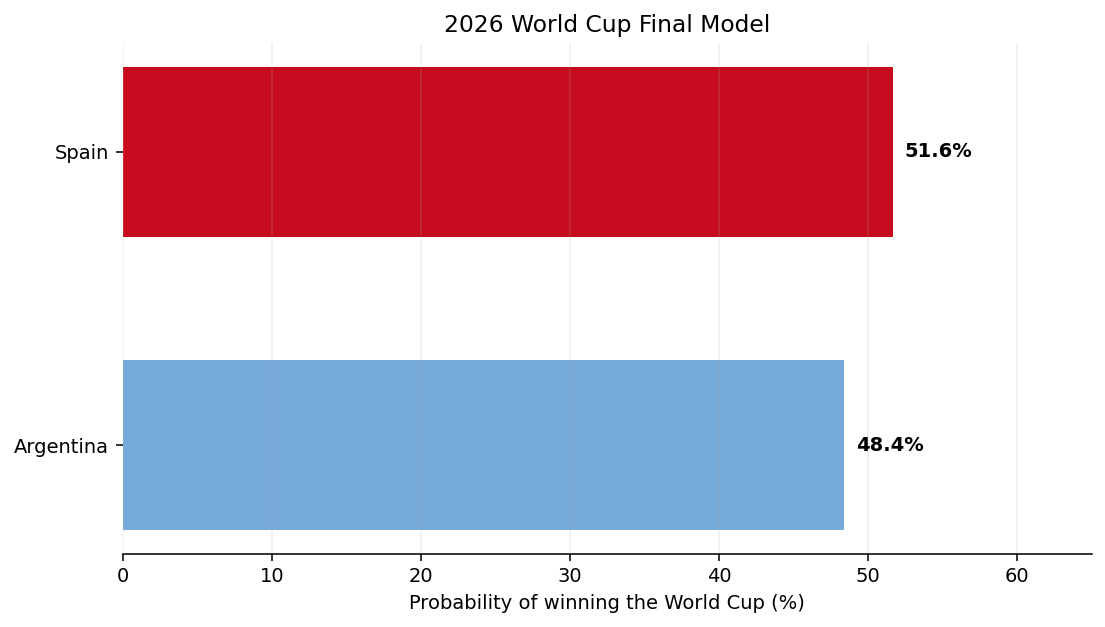

In [8]:
import matplotlib.pyplot as plt

winner_probs = pd.Series(report['eventual_winner_probability']).sort_values() * 100
colors = ['#75AADB' if team == 'Argentina' else '#C60B1E' for team in winner_probs.index]
fig, ax = plt.subplots(figsize=(8, 4.6))
bars = ax.barh(winner_probs.index, winner_probs.values, color=colors, height=0.58)
ax.set_xlim(0, 65)
ax.set_xlabel('Probability of winning the World Cup (%)')
ax.set_title('2026 World Cup Final Model')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.2)
for bar, value in zip(bars, winner_probs.values):
    ax.text(value + 0.8, bar.get_y() + bar.get_height()/2, f'{value:.1f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()


## How to read the result

This is a probability estimate, not a certainty. A prediction near 50–50 means the model sees the final as genuinely close. Accuracy measures whether the most likely class was right; log loss also rewards honest probabilities and strongly penalizes confident mistakes.